In [3]:
#Анализ файла Iris Species

In [5]:
import pandas as pd
df = pd.read_csv("Iris.csv")

In [6]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df.shape #размер датасета, где 150 строк и 6 признаков (колонок)

(150, 6)

In [9]:
df.columns #типы признаков - всего 6 штук

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [10]:
df.info() #общая информация

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [20]:
a = df.isnull().sum() #здесь мы посмотрели есть ли пропуски по столбцам (пропусков нет)
a.head(7)

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [27]:
f = df['Species'].value_counts() # т.к. вывод 50,50,50, то наш класс сбалансирован 
f.head()

SepalLengthCm
5.0    10
5.1     9
6.3     9
5.7     8
6.7     8
Name: count, dtype: int64

In [30]:
df.duplicated().sum() 

np.int64(0)

In [31]:
df.describe() #проверяем числовые признаки

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


<Axes: >

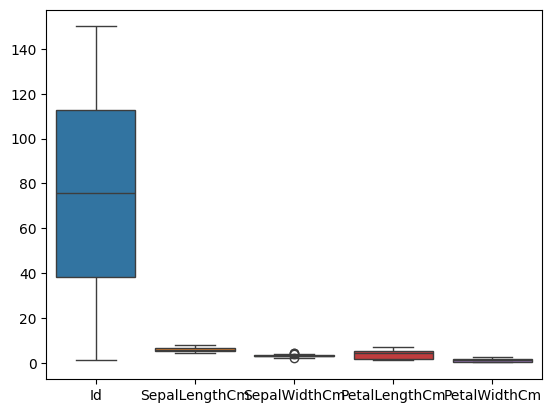

In [34]:
import seaborn as sns
sns.boxplot(data=df.select_dtypes(include="number")) #по этому графику можно понятт, что аномалий и выбросов нет

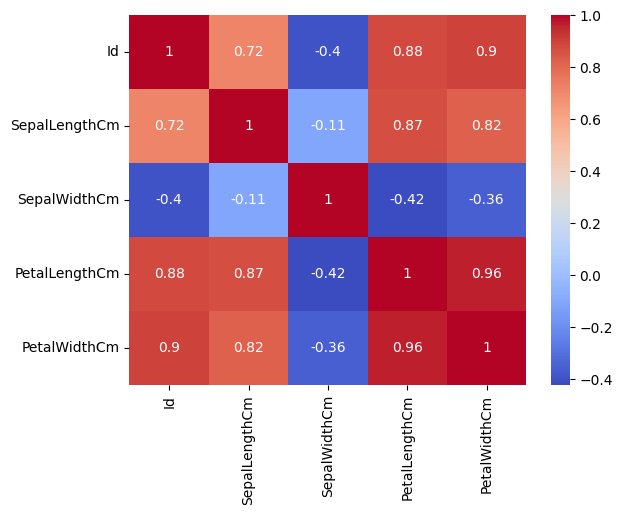

In [40]:
import matplotlib.pyplot as plt
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm") #корреляция между столбцами
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Species_encoded"] = le.fit_transform(df["Species"])
df[["Species", "Species_encoded"]].head(51) #здесь мы будем кодировать по LabelEncoded, т.к нам нужно потом работать с этими данным, но из-за того, что они текстовые программа не сможет их анализировать => нам нужно закодировать их в числовые данные

,Species,Species_encoded
0,Iris-setosa,0
1,Iris-setosa,0
2,Iris-setosa,0
3,Iris-setosa,0
4,Iris-setosa,0
5,Iris-setosa,0
6,Iris-setosa,0
7,Iris-setosa,0
8,Iris-setosa,0
9,Iris-setosa,0


In [24]:
# Сейчас мы будем делать train/test split для того, чтобы позже использовать новыые данные (test) для обучения модели. Без train/test модель не сможет корректно обучаться, т.к. расстояние между новыми и старыми данными будет 0.

from sklearn.model_selection import train_test_split

X = df.drop(columns=["Species", "Species_encoded", "Id"]) #убираем эти колонки, т.к. к ним должна стремиться модель и не видеть их данные
y = df["Species_encoded"] # здесь мы устанавливаем цель, к чему должна стремиться обучающаяся модель

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=45) # где X - это признаки для обучения и теста, а y - ответы, к чему стрематься

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)




(60, 4)
(90, 4)
(60,)
(90,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #тут мы не используем fit, т.к. при тестировании модель не будет знать исходных данных



In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, weights = "distance")
knn.fit(X_train_scaled, y_train)

score = knn.score(X_test_scaled, y_test)
print(score)

0.9444444444444444


In [45]:
knn_euclid = KNeighborsClassifier(n_neighbors=7, metric = "euclidean")
knn_euclid.fit(X_train_scaled, y_train)
score_euclid = knn_euclid.score(X_test_scaled, y_test)

knn_manh = KNeighborsClassifier(n_neighbors=3, metric = "manhattan")
knn_manh.fit(X_train_scaled, y_train)
score_manh = knn_manh.score(X_test_scaled, y_test)

print("Euclidean: ", score_euclid)
print("Manhattan: ", score_manh)

Euclidean:  0.9666666666666667
Manhattan:  0.9666666666666667


In [46]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors = 5)
scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)

print(scores)
print(scores.mean())

[1.         1.         1.         0.91666667 0.91666667]
0.9666666666666666


In [51]:
# Сейчас с помощью GridSearchCV мы сможем подобрать наилучшую комбинацию без ручного ввода

from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
param_grid = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=10,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV score:", grid.best_score_)

best_knn = grid.best_estimator_
test_score = best_knn.score(X_test_scaled, y_test)

print("Test score:", test_score)

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Лучший CV score: 0.95
Test score: 0.9555555555555556


In [56]:
# Проверим вклад масштабирования

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)
score_no_scalling = knn.score(X_test, y_test)
print("Без масштабирования:", score_no_scalling)


Без масштабирования: 0.9888888888888889


In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)
score_scaling = knn.score(X_test_scaled, y_test)

print("С масштабированием:", score_scaling)

С масштабированием: 0.9555555555555556


In [ ]:
# С масшат-ем значение меньше в данном случае, т.к оно делает вклад признаков более равномерным, нежели без него. 
# Как итог, можно сказать, что изначально наши класс был сбалансирован (50,50,50) и поэтому их обработка была заранее неплохой
# Также можно отметить, что из-за небольшой кол-ва точек (150) 